<a href="https://colab.research.google.com/github/mitalidaduria/nlp-payments-lab/blob/main/Prophet_Time_Series_%E2%80%94_payment_volume_forecasting_%2B_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/prophet/make_holidays.py:49: UserWarning: Requested Holidays are available only from 2001 to 2035.
  return set(country_holidays(language="en_US", years=np.arange(1995, 2045)).values())
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


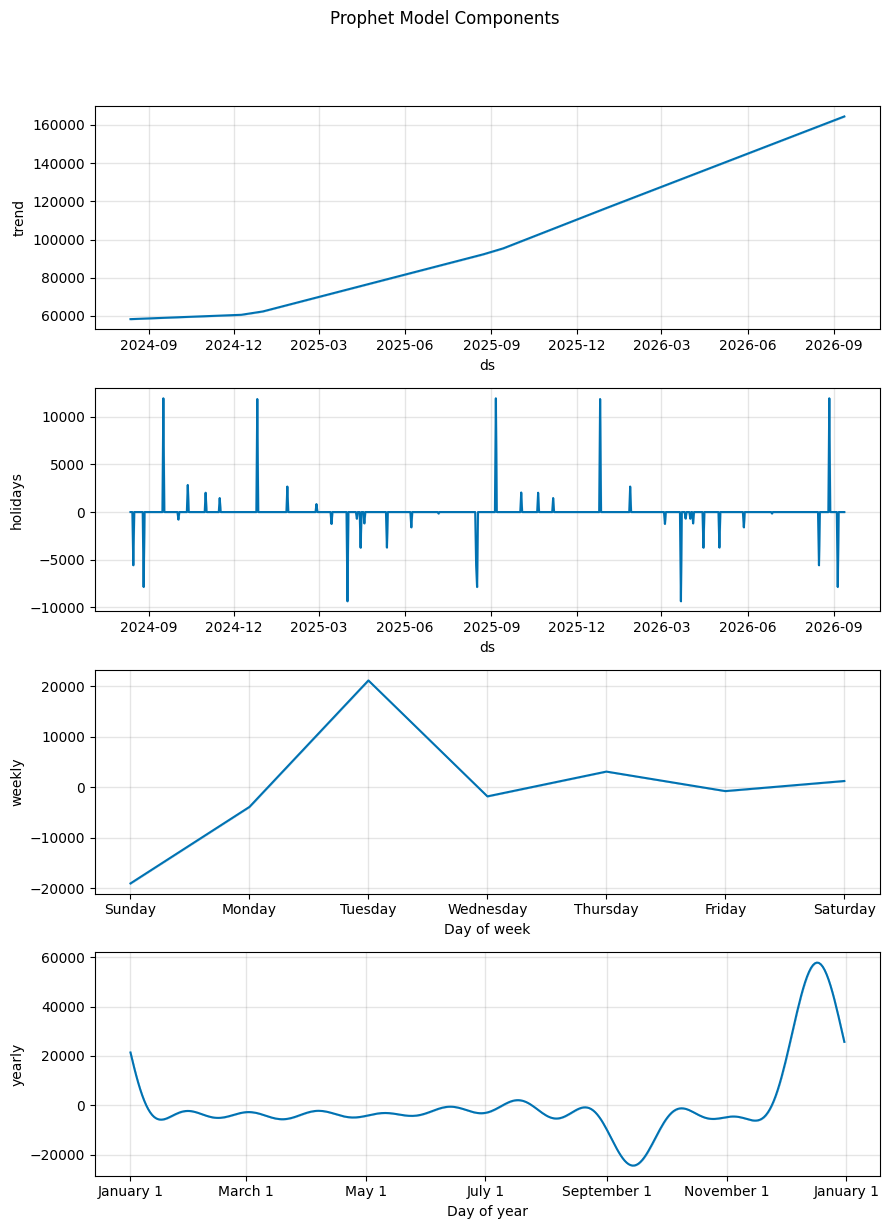

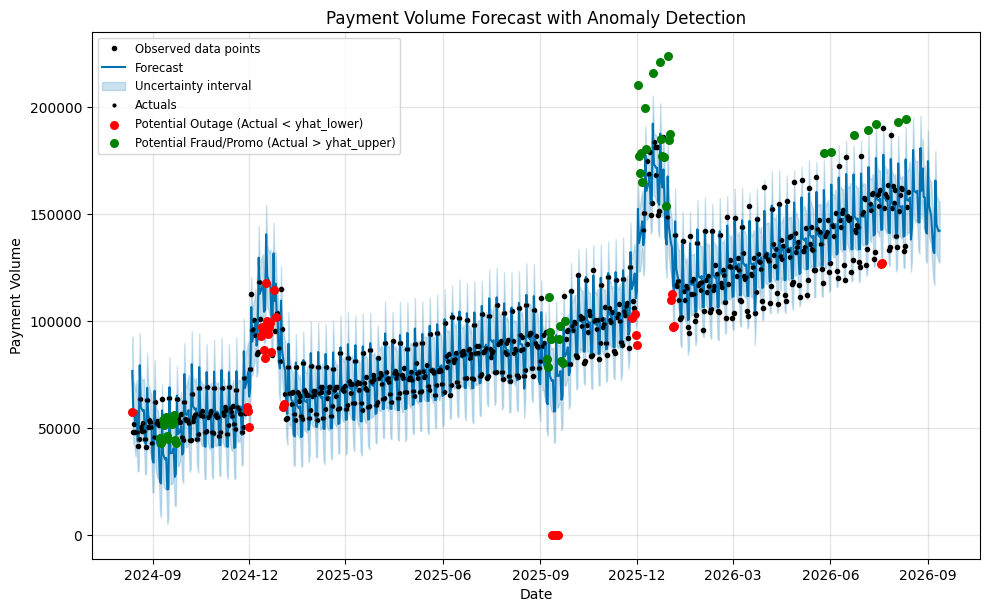

Anomaly Detection Summary (Historical Data):
anomaly
Normal                   649
Potential Fraud/Promo     46
Potential Outage          36
Name: count, dtype: int64

Forecast with Anomaly Flags (last 10 rows):
                            ds       y           yhat     yhat_lower  \
721 2026-08-03 18:28:19.429663  193008  173791.268454  157919.419141   
722 2026-08-04 18:28:19.429663  151643  154187.839586  140581.347820   
723 2026-08-05 18:28:19.429663  158841  153398.291823  139617.629808   
724 2026-08-06 18:28:19.429663  162273  152869.948797  138506.081494   
725 2026-08-07 18:28:19.429663  161633  153921.238728  139367.730032   
726 2026-08-08 18:28:19.429663  132629  139526.552858  124960.886038   
727 2026-08-09 18:28:19.429663  135290  139985.065767  124718.384790   
728 2026-08-10 18:28:19.429663  194629  175635.283377  161141.661273   
729 2026-08-11 18:28:19.429663  153144  156632.487595  140216.308048   
730 2026-08-12 18:28:19.429663  160617  156394.770512  141660.966861 

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import holidays as hdays
from datetime import datetime, timedelta

# --- 1. Generate 2 years of daily payment volume data ---

# Define parameters
current_date = pd.Timestamp.today()
start_date = current_date - pd.DateOffset(years=2)
end_date = current_date
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
n_days = len(date_range)

base_volume_start = 50000
monthly_growth_rate = 0.05
daily_growth_factor = (1 + monthly_growth_rate)**(1/30.4375) # Approximate daily equivalent

# Create a DataFrame for the data
df = pd.DataFrame({'ds': date_range})

# Base trend
df['base_trend'] = base_volume_start * (daily_growth_factor**np.arange(n_days))

# Weekly seasonality
# Monday +20%, weekend -15%
df['day_of_week'] = df['ds'].dt.day_name()
weekly_seasonality_factors = {
    'Monday': 1.20,
    'Tuesday': 1.0,
    'Wednesday': 1.0,
    'Thursday': 1.0,
    'Friday': 1.0,
    'Saturday': 0.85, # -15%
    'Sunday': 0.85  # -15%
}
df['weekly_seasonality'] = df['day_of_week'].map(weekly_seasonality_factors)

# Annual seasonality (December +60%)
df['month'] = df['ds'].dt.month
df['annual_seasonality'] = df['month'].apply(lambda x: 1.60 if x == 12 else 1.0)

# Combine trend and seasonality
df['volume'] = df['base_trend'] * df['weekly_seasonality'] * df['annual_seasonality']

# Inject promotional spikes
promo_spike_factor = 1.5 # 50% increase for main promo day
promo_dates_list = []

# Republic Day (India)
for year in range(start_date.year, end_date.year + 1):
    republic_day = pd.Timestamp(f'{year}-01-26')
    if start_date <= republic_day <= end_date:
        promo_dates_list.append(republic_day)

# Diwali (India - main day for Laxmi Puja, which varies)
# Specific dates for 2022, 2023, 2024
if start_date.year <= 2022 <= end_date.year: promo_dates_list.append(pd.Timestamp('2022-10-24')) # Diwali 2022
if start_date.year <= 2023 <= end_date.year: promo_dates_list.append(pd.Timestamp('2023-11-12')) # Diwali 2023
if start_date.year <= 2024 <= end_date.year: promo_dates_list.append(pd.Timestamp('2024-11-01')) # Diwali 2024

# Black Friday (Last Friday of November)
for year in range(start_date.year, end_date.year + 1):
    last_day_nov = pd.Timestamp(f'{year}-11-30')
    black_friday = last_day_nov - pd.DateOffset(days=(last_day_nov.dayofweek - 4) % 7)
    if start_date <= black_friday <= end_date:
        promo_dates_list.append(black_friday)

promo_dates_series = pd.Series(promo_dates_list).unique() # Remove duplicates

# Apply promotional spikes
for p_date in promo_dates_series:
    # Ensure spike is applied only if date exists in dataframe
    if p_date in df['ds'].values:
        df.loc[df['ds'] == p_date, 'volume'] *= promo_spike_factor
        # Add a smaller bump for the day before/after, if they exist
        if p_date - timedelta(days=1) in df['ds'].values:
             df.loc[df['ds'] == p_date - timedelta(days=1), 'volume'] *= 1.25
        if p_date + timedelta(days=1) in df['ds'].values:
            df.loc[df['ds'] == p_date + timedelta(days=1), 'volume'] *= 1.25

# Inject gateway outage gap (7 missing days)
# Choose a 7-day period slightly offset from the middle of the data
outage_start_index = n_days // 2 + 30
outage_start_date = df['ds'].iloc[outage_start_index]
outage_end_date = outage_start_date + timedelta(days=6) # 7 days total
df.loc[(df['ds'] >= outage_start_date) & (df['ds'] <= outage_end_date), 'volume'] = 0 # Simulate outage

# Add some random noise
df['volume'] = df['volume'] * np.random.uniform(0.95, 1.05, n_days)

# Ensure volume is non-negative and integer
df['volume'] = df['volume'].apply(lambda x: max(0, x)).round(0).astype(int)

# Prepare data for Prophet
df_prophet = df[['ds', 'volume']].copy()
df_prophet.rename(columns={'volume': 'y'}, inplace=True)

# --- 2. Fit Prophet and forecast 30 days ---

model = Prophet(yearly_seasonality=True, weekly_seasonality=True, uncertainty_samples=500)
model.add_country_holidays(country_name='IN') # Add Indian holidays

model.fit(df_prophet)

# Create future dataframe for 30 days forecast
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# --- 3. Plot components ---
# Plot the trend, weekly, and yearly components separately
fig_components = model.plot_components(forecast)
plt.suptitle('Prophet Model Components', y=1.02) # Add a suptitle for clarity
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# --- 4. Anomaly detection ---

# Merge actual values with forecast for anomaly detection
forecast_with_actual = pd.merge(df_prophet, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')

# Identify anomalies
forecast_with_actual['anomaly'] = 'Normal'
forecast_with_actual.loc[forecast_with_actual['y'] < forecast_with_actual['yhat_lower'], 'anomaly'] = 'Potential Outage'
forecast_with_actual.loc[forecast_with_actual['y'] > forecast_with_actual['yhat_upper'], 'anomaly'] = 'Potential Fraud/Promo'

# Plot forecast with anomalies
fig_forecast = model.plot(forecast)
ax = fig_forecast.gca()

# Plot actuals for the historical period
ax.plot(df_prophet['ds'], df_prophet['y'], 'k.', label='Actuals', markersize=4)

# Plot anomalies
outage_anomalies = forecast_with_actual[forecast_with_actual['anomaly'] == 'Potential Outage']
promo_anomalies = forecast_with_actual[forecast_with_actual['anomaly'] == 'Potential Fraud/Promo']

ax.scatter(outage_anomalies['ds'], outage_anomalies['y'],
           color='red', label='Potential Outage (Actual < yhat_lower)', s=30, zorder=5)
ax.scatter(promo_anomalies['ds'], promo_anomalies['y'],
           color='green', label='Potential Fraud/Promo (Actual > yhat_upper)', s=30, zorder=5)

ax.legend(loc='upper left', fontsize='small')
plt.title('Payment Volume Forecast with Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Payment Volume')
plt.show()

print("Anomaly Detection Summary (Historical Data):")
print(forecast_with_actual['anomaly'].value_counts())

# Display the last few rows of the forecast with anomaly flags
print("\nForecast with Anomaly Flags (last 10 rows):")
print(forecast_with_actual.tail(10))

# Display the forecast for the next 30 days separately
print("\n30-day Forecast:")
print(forecast.tail(30)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])